# Estudio 01 — Fundamentos de Redes Neuronales
**Diplomado Superior en Redes Neuronales Artificiales y Deep Learning**  
Módulo 4 | Diana Blanco

---
## 🧠 ¿Qué es una neurona artificial?

Una neurona artificial es la unidad fundamental de una red neuronal. Recibe entradas, las multiplica por **pesos**, suma un **sesgo (bias)**, y aplica una **función de activación** para producir una salida.

### Componentes:
- **Entradas ($x_1, x_2, ..., x_n$):** Valores que recibe la neurona
- **Pesos ($w_1, w_2, ..., w_n$):** Coeficientes que determinan la importancia de cada entrada
- **Sesgo ($b$):** Término que permite desplazar la activación
- **Función de activación ($f$):** Transformación no lineal (ReLU, Sigmoid, Tanh, Softmax)
- **Salida ($y = f(\sum w_i x_i + b)$):** Resultado final

### Arquitectura MLP (Perceptrón Multicapa)

Un MLP está compuesto por:
1. **Capa de entrada:** Recibe los datos (una neurona por feature)
2. **Capas ocultas:** Aprenden representaciones intermedias
3. **Capa de salida:** Produce la predicción final

```
Entrada → [Capa Oculta 1] → [Capa Oculta 2] → ... → Salida
```

> Cada conexión tiene un peso asociado. El entrenamiento consiste en ajustar estos pesos para minimizar el error.

In [1]:
# MACHOTE: Configuración inicial del entorno
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from modulo4_libreria import *

# Ver plataforma y configuración
INFO = setup_completo()

  🔧 CONFIGURACIÓN AUTOMÁTICA — Módulo 4 Deep Learning
🖥️  Plataforma: Local (VSCode / Jupyter)
✅ Reproducibilidad configurada (semilla=42)
⚠️  No se detectó GPU — se usará CPU
🔧 Dispositivo activo: CPU

📁 Rutas:
   base: /home/usr-lbr-maq19/Diplomado-RNA/Modulo-4/Estudio
   datos: /home/usr-lbr-maq19/Diplomado-RNA/Modulo-4/Estudio/Material
   modelos: /home/usr-lbr-maq19/Diplomado-RNA/Modulo-4/Estudio/modelos
   outputs: /home/usr-lbr-maq19/Diplomado-RNA/Modulo-4/Estudio/outputs
  ✅ Todo listo para trabajar


2026-06-13 08:08:19.748322: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# MACHOTE: Demostración de detección de plataforma
plataforma = detectar_plataforma()
print(f"¿Estamos en Colab? {plataforma['en_colab']}")
print(f"Plataforma: {plataforma['plataforma']}")
print(f"Ruta de datos: {plataforma['rutas']['datos']}")

🖥️  Plataforma: Local (VSCode / Jupyter)
¿Estamos en Colab? False
Plataforma: local
Ruta de datos: /home/usr-lbr-maq19/Diplomado-RNA/Modulo-4/Estudio/Material


In [3]:
# MACHOTE: Generar dataset sintético de clasificación
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=15,
    n_redundant=3, n_classes=3, random_state=42
)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Clases únicas: {np.unique(y)}")

# Dividir en train/val/test
datos = train_val_test_split(X, y, test_size=0.2, val_size=0.1)
X_train, X_val, X_test = datos['X_train'], datos['X_val'], datos['X_test']
y_train, y_val, y_test = datos['y_train'], datos['y_val'], datos['y_test']

Features shape: (1000, 20)
Labels shape: (1000,)
Clases únicas: [0 1 2]
📊 Train: 700 | Val: 100 | Test: 200


In [4]:
# MACHOTE: Construir MLP con nuestra librería
modelo_mlp = crear_mlp(
    input_shape=(20,),
    num_clases=3,
    capas_ocultas=[128, 64, 32],
    dropout=0.3
)

modelo_mlp.summary()

Model: "MLP_Basico"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,019 (54.76 KB)

 Trainable params: 13,571 (53.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# MACHOTE: Compilar y entrenar el MLP
historial = compilar_y_entrenar(
    modelo_mlp, X_train, y_train, X_val, y_val,
    num_clases=3, lr=0.001, epochs=30, batch_size=32,
    early_stop_paciencia=5
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3771 - loss: 1.5394 - val_accuracy: 0.4200 - val_loss: 1.1325 - learning_rate: 0.0010
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4871 - loss: 1.1610 - val_accuracy: 0.5500 - val_loss: 0.9627 - learning_rate: 0.0010
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 1.0287 - val_accuracy: 0.6200 - val_loss: 0.8632 - learning_rate: 0.0010
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5757 - loss: 0.9595 - val_accuracy: 0.6500 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.9505 - val_accuracy: 0.6800 - val_loss: 0.7776 - learning_rate: 0.0010
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6429 - loss: 0.8354 - val_accuracy: 0.7000 - val_loss: 0.7401 - learning_rate: 0.0010
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6471 - loss: 0.7721 - val_accuracy

/home/usr-lbr-maq19/Diplomado-RNA/Modulo-4/modulo4_libreria.py:722: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/usr-lbr-maq19/anaconda3/envs/diplomado_rna/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


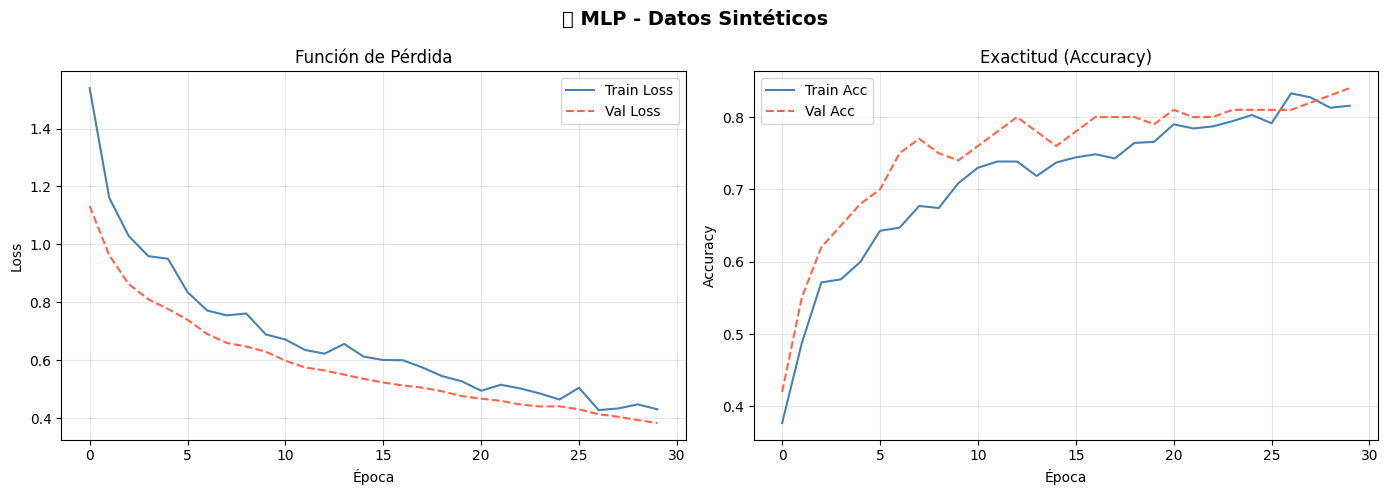

In [6]:
# MACHOTE: Graficar historia de entrenamiento
graficar_historia(historial, titulo="MLP - Datos Sintéticos")


🎯 Accuracy en test: 0.8350 (83.50%)

📋 Reporte de clasificación:
              precision    recall  f1-score   support

     Clase 0       0.92      0.84      0.88        73
     Clase 1       0.85      0.82      0.83        73
     Clase 2       0.73      0.85      0.79        54

    accuracy                           0.83       200
   macro avg       0.83      0.84      0.83       200
weighted avg       0.84      0.83      0.84       200



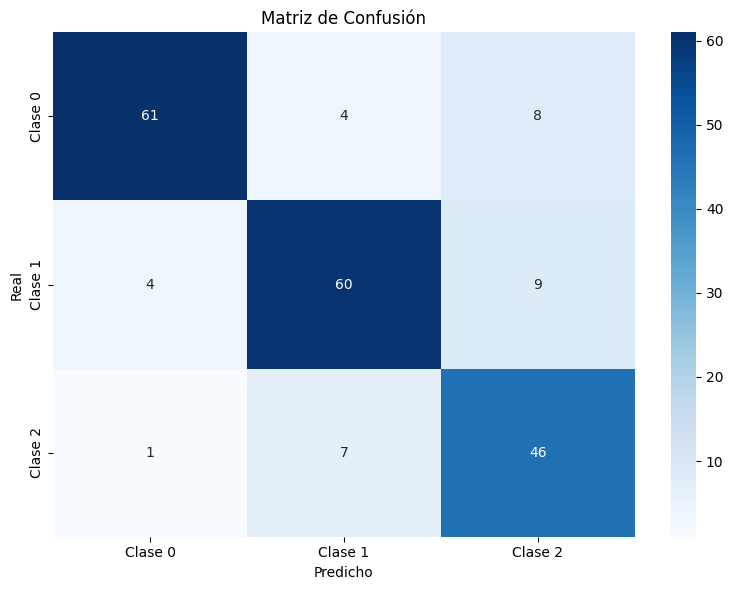

In [7]:
# MACHOTE: Evaluar el modelo en test
predicciones = evaluar_clasificacion(
    modelo_mlp, X_test, y_test,
    nombres_clases=['Clase 0', 'Clase 1', 'Clase 2']
)

---
## 📌 Resumen de conceptos clave

| Concepto | Descripción |
|---|---|
| **Neurona** | Unidad básica: $y = f(\sum w_i x_i + b)$ |
| **Pesos** | Parámetros aprendidos que multiplican las entradas |
| **Bias** | Término de desplazamiento |
| **Activación** | Función no lineal (ReLU, Sigmoid, Softmax) |
| **MLP** | Red feed-forward con capas totalmente conectadas |
| **Forward pass** | Propagación de entrada a salida |
| **Backpropagation** | Ajuste de pesos mediante gradientes |

---
## ✏️ Ejercicios (Tarea)

1. Cambia el número de capas ocultas y neuronas. ¿Cómo afecta al accuracy?
2. Prueba con `dropout=0.0` vs `dropout=0.5`. ¿Notas overfitting?
3. Genera un dataset con `n_classes=2` (clasificación binaria). ¿Cambia la activación de salida?
4. Aumenta `n_samples` a 5000. ¿Mejora la precisión?

In [ ]:
# TODO: Experimenta con diferentes arquitecturas MLP
# 1. Crea un MLP con capas [256, 128, 64, 32]
# 2. Entrénalo y compara accuracy
# 3. Prueba con dropout=0.5

# === ESCRIBE TU CÓDIGO AQUÍ ===



# ════════════════════════════════════